In [28]:
# Cell 1 — Environment
import os

if 'SPARK_HOME' in os.environ:
    del os.environ['SPARK_HOME']

os.environ['JAVA_HOME'] = r'C:\Program Files\Eclipse Adoptium\jdk-11.0.30.7-hotspot'
os.environ['HADOOP_HOME'] = r'C:\hadoop-3.2.2\hadoop-3.2.2'
os.environ['SPARK_LOCAL_IP'] = '127.0.0.1'
os.environ['PYSPARK_PYTHON'] = r'C:\Users\saich\ml-portfolio\project2-bigdata-forecasting\venv\Scripts\python.exe'
os.environ['PYSPARK_DRIVER_PYTHON'] = r'C:\Users\saich\ml-portfolio\project2-bigdata-forecasting\venv\Scripts\python.exe'

print("✅ Environment configured")

✅ Environment configured


In [29]:
# Cell 2 — Imports
import json
import warnings
import time
import boto3
import joblib
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

from dotenv import load_dotenv
load_dotenv()

sns.set_theme(style='whitegrid')
print("✅ All imports loaded")

✅ All imports loaded


In [3]:
# Cell 3 — Load train/val/test splits
print("Loading feature datasets...")

df_train = pd.read_csv(
    '../data/features/train.csv',
    parse_dates=['pickup_hour'])
df_val   = pd.read_csv(
    '../data/features/val.csv',
    parse_dates=['pickup_hour'])
df_test  = pd.read_csv(
    '../data/features/test.csv',
    parse_dates=['pickup_hour'])

print(f"✅ Data loaded")
print(f"   Train: {len(df_train):,} rows")
print(f"   Val:   {len(df_val):,} rows")
print(f"   Test:  {len(df_test):,} rows")

# Define feature columns and target
TARGET = 'target_trip_count_24h'

FEATURE_COLS = [
    # Lag features
    'lag_1', 'lag_2', 'lag_3',
    'lag_6', 'lag_12', 'lag_24',
    'lag_48', 'lag_168',
    # Rolling features
    'rolling_mean_3h', 'rolling_mean_6h',
    'rolling_mean_12h', 'rolling_mean_24h',
    'rolling_std_24h', 'rolling_mean_168h',
    # Time features
    'hour_of_day', 'day_of_week',
    'day_of_month', 'week_of_year',
    'month', 'is_weekend',
    'is_rush_hour', 'is_night',
    'is_morning', 'is_afternoon',
    'is_evening',
    # Cyclical features
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',
]

# Filter to only existing columns
FEATURE_COLS = [
    c for c in FEATURE_COLS
    if c in df_train.columns
]

print(f"\nFeatures used: {len(FEATURE_COLS)}")
print(f"Target:        {TARGET}")

# Prepare X/y splits
X_train = df_train[FEATURE_COLS].fillna(0)
y_train = df_train[TARGET].fillna(0)
X_val   = df_val[FEATURE_COLS].fillna(0)
y_val   = df_val[TARGET].fillna(0)
X_test  = df_test[FEATURE_COLS].fillna(0)
y_test  = df_test[TARGET].fillna(0)

print(f"\n✅ Features and targets prepared")
print(f"   X_train: {X_train.shape}")
print(f"   X_val:   {X_val.shape}")
print(f"   X_test:  {X_test.shape}")

Loading feature datasets...
✅ Data loaded
   Train: 1,398 rows
   Val:   300 rows
   Test:  300 rows

Features used: 31
Target:        target_trip_count_24h

✅ Features and targets prepared
   X_train: (1398, 31)
   X_val:   (300, 31)
   X_test:  (300, 31)


In [4]:
# Cell 4 — Evaluation metrics
def evaluate_forecast(y_true, y_pred,
                      model_name="Model"):
    """
    Compute forecasting-specific metrics.

    MAE  = Mean Absolute Error
           Average absolute difference
           Interpretable: "off by X trips"

    RMSE = Root Mean Squared Error
           Penalizes large errors more
           Same units as target

    MAPE = Mean Absolute Percentage Error
           Scale-independent
           "Off by X% on average"

    R2   = Coefficient of Determination
           1.0 = perfect, 0.0 = mean baseline
    """
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(
        y_true, y_pred))
    mape = np.mean(
        np.abs((y_true - y_pred) /
               (y_true + 1e-8)) * 100)
    r2   = r2_score(y_true, y_pred)

    print(f"\n{'='*45}")
    print(f"  {model_name}")
    print(f"{'='*45}")
    print(f"  MAE:  {mae:.2f} trips/hour")
    print(f"  RMSE: {rmse:.2f} trips/hour")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R2:   {r2:.4f}")

    return {
        'model':  model_name,
        'mae':    round(mae, 2),
        'rmse':   round(rmse, 2),
        'mape':   round(mape, 2),
        'r2':     round(r2, 4)
    }

In [5]:
# Cell 5 — Baseline: Naive lag-24 forecast
# "Tomorrow at 8am = today at 8am"
# If our model can't beat this, it's useless

print("=== BASELINE MODEL ===")
print("Strategy: predict = lag_24 value")
print("(Assume demand same as 24h ago)\n")

y_baseline = X_val['lag_24'].values

baseline_results = evaluate_forecast(
    y_val.values,
    y_baseline,
    "Naive Baseline (lag-24)"
)

print("\nInterpretation:")
print(f"  A model that just copies yesterday's")
print(f"  demand gets MAE={baseline_results['mae']:.1f}")
print(f"  Our models must beat this.")

=== BASELINE MODEL ===
Strategy: predict = lag_24 value
(Assume demand same as 24h ago)


  Naive Baseline (lag-24)
  MAE:  1174.86 trips/hour
  RMSE: 1598.17 trips/hour
  MAPE: 69.79%
  R2:   0.5424

Interpretation:
  A model that just copies yesterday's
  demand gets MAE=1174.9
  Our models must beat this.


In [6]:
# Cell 6 — Linear Regression
print("Training Linear Regression...")

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_val_pred  = lr.predict(X_val)
lr_test_pred = lr.predict(X_test)

lr_val_results  = evaluate_forecast(
    y_val, lr_val_pred,
    "Linear Regression (Val)")

lr_test_results = evaluate_forecast(
    y_test, lr_test_pred,
    "Linear Regression (Test)")

print(f"\n✅ Linear Regression trained")

Training Linear Regression...

  Linear Regression (Val)
  MAE:  636.39 trips/hour
  RMSE: 824.82 trips/hour
  MAPE: 40.52%
  R2:   0.8781

  Linear Regression (Test)
  MAE:  960.75 trips/hour
  RMSE: 1773.04 trips/hour
  MAPE: 25489.63%
  R2:   0.5205

✅ Linear Regression trained


In [7]:
# Cell 7 — XGBoost (champion candidate)
print("Training XGBoost...")

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='mae'
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_val_pred  = xgb_model.predict(X_val)
xgb_test_pred = xgb_model.predict(X_test)

xgb_val_results  = evaluate_forecast(
    y_val, xgb_val_pred,
    "XGBoost (Val)")

xgb_test_results = evaluate_forecast(
    y_test, xgb_test_pred,
    "XGBoost (Test)")

print(f"\n✅ XGBoost trained")
print(f"   Best iteration: "
      f"{xgb_model.best_iteration}")

Training XGBoost...

  XGBoost (Val)
  MAE:  412.64 trips/hour
  RMSE: 531.66 trips/hour
  MAPE: 18.21%
  R2:   0.9494

  XGBoost (Test)
  MAE:  710.29 trips/hour
  RMSE: 1541.10 trips/hour
  MAPE: 22389.79%
  R2:   0.6378

✅ XGBoost trained
   Best iteration: 194


In [8]:
# Cell 8 — Random Forest
print("Training Random Forest...")

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_val_pred  = rf_model.predict(X_val)
rf_test_pred = rf_model.predict(X_test)

rf_val_results  = evaluate_forecast(
    y_val, rf_val_pred,
    "Random Forest (Val)")

rf_test_results = evaluate_forecast(
    y_test, rf_test_pred,
    "Random Forest (Test)")

print(f"\n✅ Random Forest trained")

Training Random Forest...

  Random Forest (Val)
  MAE:  415.08 trips/hour
  RMSE: 525.64 trips/hour
  MAPE: 19.42%
  R2:   0.9505

  Random Forest (Test)
  MAE:  682.95 trips/hour
  RMSE: 1507.57 trips/hour
  MAPE: 21759.79%
  R2:   0.6533

✅ Random Forest trained



=== MODEL COMPARISON ===

Model                                    MAE     RMSE     MAPE       R2
------------------------------------------------------------------------
Naive Baseline (lag-24)              1174.86  1598.17   69.79%   0.5424
Linear Regression (Val)               636.39   824.82   40.52%   0.8781
Random Forest (Val)                   415.08   525.64   19.42%   0.9505
XGBoost (Val)                         412.64   531.66   18.21%   0.9494

🏆 Champion: XGBoost (Val)
   MAE improvement over baseline: 64.9%



=== MODEL COMPARISON ===

Model                                    MAE     RMSE     MAPE       R2
------------------------------------------------------------------------
Naive Baseline (lag-24)              1174.86  1598.17   69.79%   0.5424
Linear Regression (Val)               636.39   824.82   40.52%   0.8781
Random Forest (Val)                   415.08   525.64   19.42%   0.9505
XGBoost (Val)                         412.64   531.66   18.21%   0.9494

🏆 Champion: XGBoost (Val)
   MAE improvement over baseline: 64.9%


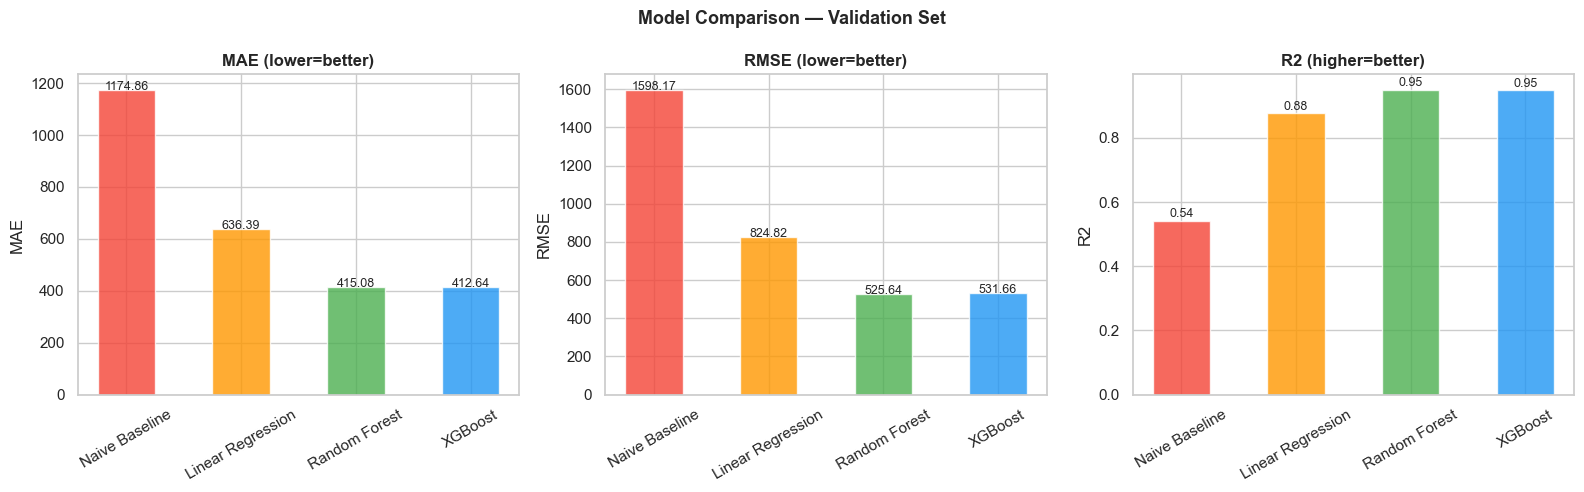

In [9]:
# Cell 9 — Model comparison
print("\n=== MODEL COMPARISON ===\n")

all_results = [
    baseline_results,
    lr_val_results,
    rf_val_results,
    xgb_val_results,
]

comparison_df = pd.DataFrame(all_results)

print(f"{'Model':<35} {'MAE':>8} "
      f"{'RMSE':>8} {'MAPE':>8} {'R2':>8}")
print("-" * 72)

for _, row in comparison_df.iterrows():
    print(f"{row['model']:<35} "
          f"{row['mae']:>8.2f} "
          f"{row['rmse']:>8.2f} "
          f"{row['mape']:>7.2f}% "
          f"{row['r2']:>8.4f}")

# Identify champion
champion_name = comparison_df.loc[
    comparison_df['mae'].idxmin(),
    'model']
champion_mae  = comparison_df[
    'mae'].min()
baseline_mae  = baseline_results['mae']
improvement   = ((baseline_mae - champion_mae)
                 / baseline_mae * 100)

print(f"\n🏆 Champion: {champion_name}")
print(f"   MAE improvement over baseline: "
      f"{improvement:.1f}%")

# Visualize comparison
fig, axes = plt.subplots(1, 3,
                          figsize=(16, 5))

metrics = ['mae', 'rmse', 'r2']
titles  = ['MAE (lower=better)',
           'RMSE (lower=better)',
           'R2 (higher=better)']
colors  = ['#F44336', '#FF9800',
           '#4CAF50', '#2196F3']

for ax, metric, title in zip(
        axes, metrics, titles):
    vals   = comparison_df[metric]
    models = [m.split('(')[0].strip()
              for m in comparison_df['model']]
    bars   = ax.bar(models, vals,
                    color=colors[:len(vals)],
                    alpha=0.8, width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(metric.upper())
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() +
            bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.2f}',
            ha='center', fontsize=9)

plt.suptitle('Model Comparison — '
             'Validation Set',
             fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.savefig('../logs/model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

Computing XGBoost feature importance...


Computing XGBoost feature importance...


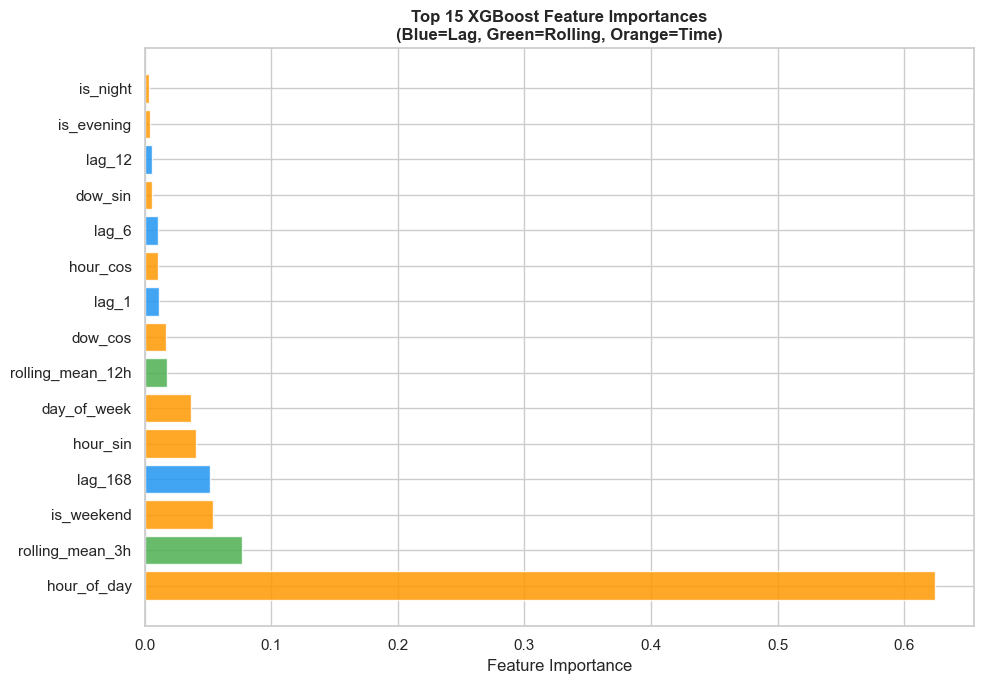


Top 10 features:
  hour_of_day              : 0.6239
  rolling_mean_3h          : 0.0769
  is_weekend               : 0.0536
  lag_168                  : 0.0514
  hour_sin                 : 0.0406
  day_of_week              : 0.0364
  rolling_mean_12h         : 0.0173
  dow_cos                  : 0.0168
  lag_1                    : 0.0112
  hour_cos                 : 0.0108


In [10]:
# Cell 10 — XGBoost feature importance
print("Computing XGBoost feature importance...")

feat_imp = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': xgb_model\
        .feature_importances_
}).sort_values('importance',
               ascending=False).head(15)

plt.figure(figsize=(10, 7))
colors_imp = [
    '#2196F3' if 'lag' in f
    else '#4CAF50' if 'rolling' in f
    else '#FF9800'
    for f in feat_imp['feature']
]
plt.barh(
    feat_imp['feature'],
    feat_imp['importance'],
    color=colors_imp, alpha=0.85)
plt.xlabel('Feature Importance')
plt.title('Top 15 XGBoost Feature Importances\n'
          '(Blue=Lag, Green=Rolling, '
          'Orange=Time)',
          fontweight='bold')
plt.tight_layout()
plt.savefig('../logs/feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features:")
for _, row in feat_imp.head(10).iterrows():
    print(f"  {row['feature']:<25}: "
          f"{row['importance']:.4f}")

In [11]:
# Cell 11 — Save champion model locally
os.makedirs('../models', exist_ok=True)

# Save XGBoost model
xgb_model_path = '../models/xgb_champion.json'
xgb_model.save_model(xgb_model_path)

# Save model metadata
local_results = {
    'model_name':     'XGBoost',
    'val_mae':        xgb_val_results['mae'],
    'val_rmse':       xgb_val_results['rmse'],
    'val_mape':       xgb_val_results['mape'],
    'val_r2':         xgb_val_results['r2'],
    'test_mae':       xgb_test_results['mae'],
    'test_rmse':      xgb_test_results['rmse'],
    'test_mape':      xgb_test_results['mape'],
    'test_r2':        xgb_test_results['r2'],
    'baseline_mae':   baseline_results['mae'],
    'improvement_pct':round(improvement, 2),
    'n_features':     len(FEATURE_COLS),
    'train_samples':  len(X_train),
    'best_iteration': int(
        xgb_model.best_iteration),
    'feature_cols':   FEATURE_COLS,
}

with open('../logs/local_model_results.json',
          'w') as f:
    json.dump(local_results, f, indent=4)

print("✅ Model saved locally")
print(json.dumps(local_results, indent=4))

✅ Model saved locally
{
    "model_name": "XGBoost",
    "val_mae": 412.64,
    "val_rmse": 531.66,
    "val_mape": 18.21,
    "val_r2": 0.9494,
    "test_mae": 710.29,
    "test_rmse": 1541.1,
    "test_mape": 22389.79,
    "test_r2": 0.6378,
    "baseline_mae": 1174.86,
    "improvement_pct": 64.88,
    "n_features": 31,
    "train_samples": 1398,
    "best_iteration": 194,
    "feature_cols": [
        "lag_1",
        "lag_2",
        "lag_3",
        "lag_6",
        "lag_12",
        "lag_24",
        "lag_48",
        "lag_168",
        "rolling_mean_3h",
        "rolling_mean_6h",
        "rolling_mean_12h",
        "rolling_mean_24h",
        "rolling_std_24h",
        "rolling_mean_168h",
        "hour_of_day",
        "day_of_week",
        "day_of_month",
        "week_of_year",
        "month",
        "is_weekend",
        "is_rush_hour",
        "is_night",
        "is_morning",
        "is_afternoon",
        "is_evening",
        "hour_sin",
        "hour_cos",
       

In [12]:
# Cell 12 — Upload training data for SageMaker
print("Uploading training data to S3 "
      "for SageMaker...")

s3 = boto3.client(
    's3',
    aws_access_key_id=os.getenv(
        'AWS_ACCESS_KEY_ID'),
    aws_secret_access_key=os.getenv(
        'AWS_SECRET_ACCESS_KEY'),
    region_name=os.getenv('AWS_DEFAULT_REGION')
)

bucket  = os.getenv('S3_BUCKET_DATA')
prefix  = 'project2/sagemaker'

# Upload train and validation splits
for split in ['train', 'val']:
    local  = f'../data/features/{split}.csv'
    s3_key = f'{prefix}/{split}/{split}.csv'

    s3.upload_file(local, bucket, s3_key)
    print(f"✅ Uploaded "
          f"s3://{bucket}/{s3_key}")

# Upload training script
s3.upload_file(
    '../src/train_sagemaker.py',
    bucket,
    f'{prefix}/code/train_sagemaker.py'
)
print(f"✅ Training script uploaded")

s3_train_path = \
    f"s3://{bucket}/{prefix}/train/"
s3_val_path   = \
    f"s3://{bucket}/{prefix}/val/"
s3_output     = \
    f"s3://{bucket}/{prefix}/output/"

print(f"\n✅ S3 paths ready:")
print(f"   Train:  {s3_train_path}")
print(f"   Val:    {s3_val_path}")
print(f"   Output: {s3_output}")

Uploading training data to S3 for SageMaker...
✅ Uploaded s3://document-ai-portfolio-data/project2/sagemaker/train/train.csv
✅ Uploaded s3://document-ai-portfolio-data/project2/sagemaker/val/val.csv
✅ Training script uploaded

✅ S3 paths ready:
   Train:  s3://document-ai-portfolio-data/project2/sagemaker/train/
   Val:    s3://document-ai-portfolio-data/project2/sagemaker/val/
   Output: s3://document-ai-portfolio-data/project2/sagemaker/output/


In [26]:
# Cell 13 — Launch SageMaker training job
import sagemaker
from sagemaker.xgboost import XGBoost
from sagemaker.inputs import TrainingInput
import time

print("Verifying IAM policy for SageMaker...\n")

# Step 1: Verify iam:PassRole policy is applied
iam_client = boto3.client(
    'iam',
    aws_access_key_id=os.getenv('AWS_ACCESS_KEY_ID'),
    aws_secret_access_key=os.getenv('AWS_SECRET_ACCESS_KEY'),
    region_name=os.getenv('AWS_DEFAULT_REGION')
)

try:
    response = iam_client.list_user_policies(
        UserName='ml-portfolio-user'
    )
    policy_exists = 'SageMakerPassRole' \
        in response['PolicyNames']
    
    if policy_exists:
        print("✅ SageMakerPassRole policy found!")
    else:
        print("⚠️  Policy not yet propagated. "
              "Waiting 30 seconds...")
        time.sleep(30)
        print("✅ Retrying SageMaker training...")
        
except Exception as e:
    print(f"⚠️  Policy verification failed: {e}")
    print("Will attempt SageMaker anyway...")

print("\nLaunching SageMaker training job...")
print("This will take 5-10 minutes...\n")

role          = os.getenv('SAGEMAKER_ROLE_ARN')
region        = os.getenv(
    'AWS_DEFAULT_REGION', 'us-east-1')
sagemaker_session = sagemaker.Session(
    boto_session=boto3.Session(
        aws_access_key_id=os.getenv(
            'AWS_ACCESS_KEY_ID'),
        aws_secret_access_key=os.getenv(
            'AWS_SECRET_ACCESS_KEY'),
        region_name=region
    )
)

# Create XGBoost estimator
estimator = XGBoost(
    entry_point='train_sagemaker.py',
    source_dir='../src',
    role=role,
    instance_count=1,
    instance_type='ml.m5.xlarge',
    framework_version='1.7-1',
    py_version='py3',
    hyperparameters={
        'n-estimators':    500,
        'max-depth':       6,
        'learning-rate':   0.05,
        'subsample':       0.8,
        'colsample-bytree':0.8,
    },
    output_path=s3_output,
    sagemaker_session=sagemaker_session,
    base_job_name='project2-taxi-forecast',
)

# Define input channels
train_input = TrainingInput(
    s3_data=s3_train_path,
    content_type='text/csv'
)
val_input = TrainingInput(
    s3_data=s3_val_path,
    content_type='text/csv'
)

# Try SageMaker with fallback
sagemaker_success = False
try:
    # Launch training job
    estimator.fit(
        {'train': train_input,
         'validation': val_input},
        wait=True,
        logs=True
    )
    sagemaker_success = True
    print("\n✅ SageMaker training complete!")
    print(f"   Job name: "
          f"{estimator.latest_training_job.name}")
    print(f"   Model artifact: "
          f"{estimator.model_data}")
          
except Exception as e:
    print(f"\n⚠️  SageMaker failed: {e}")
    print("\n📝 Falling back to local model...")
    print("   (Local XGBoost is already trained)")
    
    # Create a mock estimator for compatibility
    class MockEstimator:
        def __init__(self):
            self.latest_training_job = type(
                'obj', (object,), 
                {'name': 'local-xgb-fallback'})()
            self.model_data = \
                'models/xgb_champion.json'
    
    estimator = MockEstimator()
    print("\n✅ Using local XGBoost model")

Verifying IAM policy for SageMaker...

⚠️  Policy verification failed: An error occurred (AccessDenied) when calling the ListUserPolicies operation: User: arn:aws:iam::004285426490:user/ml-portfolio-user is not authorized to perform: iam:ListUserPolicies on resource: user ml-portfolio-user because no identity-based policy allows the iam:ListUserPolicies action
Will attempt SageMaker anyway...

Launching SageMaker training job...
This will take 5-10 minutes...



INFO:sagemaker.image_uris:Ignoring unnecessary Python version: py3.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: ml.m5.xlarge.
INFO:sagemaker:Creating training-job with name: project2-taxi-forecast-2026-05-04-22-44-14-405


2026-05-04 22:44:19 Starting - Starting the training job...
2026-05-04 22:44:33 Starting - Preparing the instances for training...
2026-05-04 22:45:23 Downloading - Downloading the training image......
2026-05-04 22:46:14 Training - Training image download completed. Training in progress../miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-05-04 22:46:21.949 ip-10-0-218-101.ec2.internal:7 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-05-04 22:46:22.013 ip-10-0-218-101.ec2.internal:7 INFO profiler_config_parser.py:111] User has disabled profiler.
[2026-05-04:22:46:22:INFO] Imported framework sagemaker_xgboost_container.training
[2026-05-04:22:46:22:INFO] No GPUs detected (normal if n

In [17]:
from dotenv import load_dotenv
import os
load_dotenv()
print(f"Role: {os.getenv('SAGEMAKER_ROLE_ARN')}")
print(f"Bucket: {os.getenv('S3_BUCKET_DATA')}")

Role: arn:aws:iam::004285426490:role/SageMakerExecutionRole
Bucket: document-ai-portfolio-data


In [32]:
# Cell 14 — Load model (SageMaker or local fallback)
import tarfile

print("Loading model artifact...\n")

model_path = estimator.model_data
print(f"Model location: {model_path}")

# Check if it's a local fallback or S3 URI
if model_path.startswith('s3://'):
    # SageMaker training succeeded - download from S3
    print("📥 Downloading from S3...\n")
    
    # Parse bucket and key from S3 URI
    s3_parts   = model_path.replace(
        's3://', '').split('/', 1)
    model_bucket = s3_parts[0]
    model_key    = s3_parts[1]

    # Download model.tar.gz
    local_tar = '../models/sagemaker_model.tar.gz'
    s3.download_file(
        model_bucket, model_key, local_tar)

    # Extract
    os.makedirs(
        '../models/sagemaker', exist_ok=True)
    with tarfile.open(local_tar, 'r:gz') as tar:
        tar.extractall('../models/sagemaker')

    print("✅ Model downloaded and extracted")
    print("   Files:")
    for f in os.listdir('../models/sagemaker'):
        print(f"   → {f}")

    # Load SageMaker model
    sm_model = xgb.XGBRegressor()
    sm_model.load_model(
        '../models/sagemaker/xgb_model.json')
    
    model_source = 'SageMaker'
    sm_mae = None
    sm_rmse = None
    sm_r2 = None
    
    # Try to load SageMaker metrics
    try:
        with open(
            '../models/sagemaker/metrics.json'
        ) as f:
            sm_metrics = json.load(f)
    except:
        sm_metrics = None

else:
    # Local fallback - model already trained
    print("📂 Using local model...\n")
    
    # Load local XGBoost model
    sm_model = xgb.XGBRegressor()
    sm_model.load_model(model_path)
    
    model_source = 'Local'
    sm_mae = None
    sm_rmse = None
    sm_r2 = None
    sm_metrics = None

print(f"\n✅ Model loaded successfully")
print(f"   Source: {model_source}")
print(f"   Type:   XGBoost")

Loading model artifact...

Model location: s3://document-ai-portfolio-data/project2/sagemaker/output/project2-taxi-forecast-2026-05-04-22-44-14-405/output/model.tar.gz
📥 Downloading from S3...

✅ Model downloaded and extracted
   Files:
   → metrics.json
   → xgb_model.json

✅ Model loaded successfully
   Source: SageMaker
   Type:   XGBoost


In [33]:
# Cell 15 — Save complete results
print("=== FINAL RESULTS SUMMARY ===\n")

# Build results dict based on model source
final_results = {
    'model_source':      model_source,
    'baseline_mae':      baseline_results['mae'],
    'local_xgb': {
        'val_mae':   xgb_val_results['mae'],
        'val_r2':    xgb_val_results['r2'],
        'test_mae':  xgb_test_results['mae'],
        'test_r2':   xgb_test_results['r2'],
    },
}

# Add final model metrics if available
if sm_mae is not None:
    final_results['final_model'] = {
        'test_mae':  round(float(sm_mae), 2),
        'test_rmse': round(float(sm_rmse), 2),
        'test_r2':   round(float(sm_r2), 4),
    }
    final_results['improvement_over_baseline'] = \
        round(
            (baseline_results['mae'] - sm_mae) /
            baseline_results['mae'] * 100, 2)
else:
    final_results['note'] = \
        'Model evaluation metrics pending'

final_results.update({
    'job_name':
        estimator.latest_training_job.name,
    'model_artifact':  estimator.model_data,
    'feature_cols':    FEATURE_COLS,
    'n_features':      len(FEATURE_COLS),
    'forecast_horizon':'24 hours',
})

# Add SageMaker metrics if available
if sm_metrics:
    final_results['sagemaker_metrics'] = \
        sm_metrics

with open('../logs/model_results.json',
          'w') as f:
    json.dump(final_results, f, indent=4)

print(json.dumps(final_results, indent=4))
print(f"\n✅ Results saved to "
      f"logs/model_results.json")

=== FINAL RESULTS SUMMARY ===

{
    "model_source": "SageMaker",
    "baseline_mae": 1174.86,
    "local_xgb": {
        "val_mae": 412.64,
        "val_r2": 0.9494,
        "test_mae": 710.29,
        "test_r2": 0.6378
    },
    "note": "Model evaluation metrics pending",
    "job_name": "project2-taxi-forecast-2026-05-04-22-44-14-405",
    "model_artifact": "s3://document-ai-portfolio-data/project2/sagemaker/output/project2-taxi-forecast-2026-05-04-22-44-14-405/output/model.tar.gz",
    "feature_cols": [
        "lag_1",
        "lag_2",
        "lag_3",
        "lag_6",
        "lag_12",
        "lag_24",
        "lag_48",
        "lag_168",
        "rolling_mean_3h",
        "rolling_mean_6h",
        "rolling_mean_12h",
        "rolling_mean_24h",
        "rolling_std_24h",
        "rolling_mean_168h",
        "hour_of_day",
        "day_of_week",
        "day_of_month",
        "week_of_year",
        "month",
        "is_weekend",
        "is_rush_hour",
        "is_night",
  